In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import os


In [9]:
testnum = "Test-1"
model_dir = "Test-1/models"
plot_dir = "Test-1/plots"

In [10]:

# Create directory to save results
os.makedirs(testnum, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

In [4]:
# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize and reshape the data
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode the labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


In [5]:
# Build the base CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

c:\Users\harsh\.conda\envs\Projects\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
# Train the model
history = model.fit(x_train, y_train_cat, epochs=15, batch_size=64,
                    validation_split=0.1)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.6566 - loss: 0.9287 - val_accuracy: 0.8408 - val_loss: 0.4204
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8281 - loss: 0.4735 - val_accuracy: 0.8702 - val_loss: 0.3519
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8547 - loss: 0.4073 - val_accuracy: 0.8702 - val_loss: 0.3406
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8646 - loss: 0.3738 - val_accuracy: 0.8885 - val_loss: 0.3000
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8740 - loss: 0.3432 - val_accuracy: 0.8943 - val_loss: 0.2797
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8832 - loss: 0.3259 - val_accuracy: 0.9002 - val_loss: 0.2646
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8841 - loss: 0.3147 - val_accuracy: 0.9023 - val_loss: 0.2635
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8906 - loss: 0.3034 - va

313/313 - 1s - 3ms/step - accuracy: 0.9063 - loss: 0.2537



Test Accuracy: 90.63%


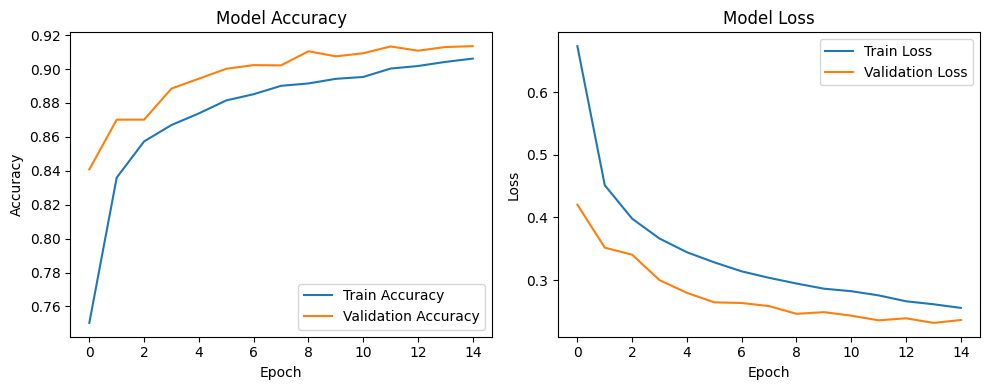

In [11]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

# Save the model
model.save(f"{model_dir}/base_cnn_model.h5")

# Plot accuracy and loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(f"{plot_dir}/base_cnn_training_plot.png")
plt.show()
